### the problem is supervised for the known and unsupervised for the unknown ones

#### tokenization maybe (they are aminoacids so maybe no)
#### Dynamic padding maybe is better than standard padding
#### Evaluation metrics during the training



In [10]:
#!pip install ipywidgets
#!pip install  esm@git+https://github.com/Biohub/esm.git@main
#!pip install httpx
#!pip install esm
#!pip install git+https://github.com/huggingface/transformers.git
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from huggingface_hub import login
from huggingface_hub import login
from esm.models.esm3 import ESM3
from esm.sdk.api import ESM3InferenceClient, ESMProtein, GenerationConfig

# login with your Hugging Face credentials
login()



In [2]:
# 1. What transformers version range does esm actually expect?
import importlib.metadata as md
for r in md.requires("esm"):
    if "transformers" in r.lower():
        print(r)

transformers @ git+https://github.com/Biohub/transformers.git@main


python -c "import transformers; print(transformers.__version__, transformers.__file__); print('esmc' in transformers.models.auto.configuration_auto.CONFIG_MAPPING_NAMES)"

In [11]:
import transformers
print(transformers.__version__, transformers.__file__)
print("esmc" in transformers.models.auto.configuration_auto.CONFIG_MAPPING_NAMES)

4.57.6 /users/antonios/miniconda3/envs/PHROGs.3.12/lib/python3.12/site-packages/transformers/__init__.py
True


In [12]:
#!pip install --upgrade transformers
!pip install  git+https://github.com/Biohub/transformers.git@main
GFP = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

model = AutoModelForMaskedLM.from_pretrained(
    "biohub/ESMC-300M",
    device_map="cuda:1",
    torch_dtype=torch.bfloat16,
).eval()

tokenizer = AutoTokenizer.from_pretrained("biohub/ESMC-300M")

inputs = tokenizer(GFP, return_tensors="pt", padding=True)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model(**inputs)

print(f"last_hidden_state shape: {tuple(output.last_hidden_state.shape)}")

  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-req-build-5i6r367r
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-req-build-5i6r367r
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
last_hidden_state shape: (1, 240, 960)


Let s try with something smaller first (500 phrogs) till we get the compputational power

In [4]:
import tarfile
import re
from pathlib import Path
import pandas as pd

# ----------------------------------------------------
# 1. Setup Paths
# ----------------------------------------------------
base_dir = Path("/users/antonios/pLMs_with_PHROGs/data")
tar_path = base_dir / "FAA_phrog.tar.gz"
tsv_path = base_dir / "phrog_annot_v4.tsv"
need_domains_path = base_dir / "phrogs_needing_domains.txt"

annot_df = pd.read_csv(tsv_path, sep="\t")
annot_map = annot_df.set_index("phrog")["annot"].to_dict()

MAX_LEN = 1024


def sequence_lengths(fasta_text: str):
    """Yield the length of each sequence in a FASTA-formatted string."""
    length = 0
    started = False
    for line in fasta_text.splitlines():
        if line.startswith(">"):
            if started:
                yield length
            length = 0
            started = True
        else:
            length += len(line.strip())
    if started:
        yield length


phrogs_needing_domains = set()
total_sequences_checked = 0
total_sequences_exceeding = 0

print(f"📦 Scanning entire archive to find PHROGs with sequences >= {MAX_LEN} aa...")

# ----------------------------------------------------
# 2. Complete Scan (No Subsampling)
# ----------------------------------------------------
with tarfile.open(tar_path, "r:gz") as t:
    for member in t.getmembers():
        if not member.isfile() or not member.name.endswith((".faa", ".fasta")):
            continue

        match = re.search(r"phrog_(\d+)\.", Path(member.name).name)
        if not match:
            continue
        phrog_id = int(match.group(1))

        content = t.extractfile(member).read().decode("utf-8")
        lengths = list(sequence_lengths(content))

        total_sequences_checked += len(lengths)
        n_exceeding = sum(1 for l in lengths if l >= MAX_LEN)
        total_sequences_exceeding += n_exceeding

        if n_exceeding:
            phrogs_needing_domains.add(phrog_id)

# ----------------------------------------------------
# 3. Write Target IDs and Report
# ----------------------------------------------------
with open(need_domains_path, "w") as f:
    for pid in sorted(phrogs_needing_domains):
        f.write(f"{pid}\n")

print("\n" + "─" * 50)
print("📊 SCAN COMPLETION REPORT")
print("─" * 50)
print(f"🔹 Total Sequences Evaluated       : {total_sequences_checked:,}")
print(f"🔹 Long Sequences Caught (>={MAX_LEN})  : {total_sequences_exceeding:,}")
print(f"🔹 PHROG Pools Requiring Trimming  : {len(phrogs_needing_domains)}")
print(f"💾 File targets list saved to      : {need_domains_path}")
print("─" * 50)


📦 Scanning entire archive to find PHROGs with sequences >= 1024 aa...

──────────────────────────────────────────────────
📊 SCAN COMPLETION REPORT
──────────────────────────────────────────────────
🔹 Total Sequences Evaluated       : 868,340
🔹 Long Sequences Caught (>=1024)  : 7,106
🔹 PHROG Pools Requiring Trimming  : 401
💾 File targets list saved to      : /users/antonios/pLMs_with_PHROGs/data/phrogs_needing_domains.txt
──────────────────────────────────────────────────


check the aminoacid sequence with more than 1024 and focus on the  functional domains

In [6]:
# import re
# import glob
# import pandas as pd

# def parse_hhr_hits(hhr_path, max_hits=10):
#     with open(hhr_path) as f:
#         lines = f.readlines()

#     hits = []
#     in_table = False
#     for line in lines:
#         if line.strip().startswith("No Hit"):
#             in_table = True
#             continue
#         if in_table:
#             if line.strip() == "" or line.startswith("No "):
#                 break
#             m = re.match(
#                 r"^\s*(\d+)\s+(.+?)\s+(\d+\.\d+)\s+([\d.eE+-]+)\s+([\d.eE+-]+)\s+"
#                 r"([\d.-]+)\s+([\d.-]+)\s+(\d+)\s+(\d+)-(\d+)\s+(\d+)-(\d+)\s+\((\d+)\)",
#                 line
#             )
#             if m:
#                 hits.append({
#                     "rank": int(m.group(1)),
#                     "hit_name": m.group(2).strip(),
#                     "prob": float(m.group(3)),
#                     "evalue": float(m.group(4)),
#                     "cols": int(m.group(8)),
#                     "q_start": int(m.group(9)),
#                     "q_end": int(m.group(10)),
#                     "t_start": int(m.group(11)),
#                     "t_end": int(m.group(12)),
#                     "t_length": int(m.group(13)),
#                 })
#             if len(hits) >= max_hits:
#                 break
#     return hits

# # Test on phrog_16
# hits = parse_hhr_hits("/users/antonios/pLMs_with_PHROGs/data/hhsearch_results/phrog_16.hhr")
# for h in hits[:5]:
#     print(h)

Input Limits: ESM3 models have a maximum sequence length, typically around 1,024 amino acids, depending on the specific model variant.

I have to identify the core part of the sequences that have >1024 aa length. thereffore I am running HH suite to identify those so that I don t just crop the N part of the sequence

Why pfam? Pfam domain coordinates would tell you exactly where that meaningful region is in each sequence, so you cut around it instead of through it.

I used the pfamA_35.0.tar.gz database to tfind the homology regions

the get_optimal_trim_window function Parses the .hhr file to find the minimum start and maximum end coordinates of all high-confidence hits (e.g., Prob > 95% or E-value < 0.001).

Pads that region out to a maximum of 1024 amino acids.

Sub-selects that window from your raw fasta sequences.

helper function

In [3]:
# ----------------------------------------------------
# 1. Improved Window Parser (Robust Column Mapping)
# ----------------------------------------------------
def get_functional_trim_window(hhr_path, max_len=1024, min_prob=95.0):
    """
    Parses an .hhr file to isolate the largest high-confidence domain
    (>= min_prob), regardless of hit-name column width.
    """
    query_length = None
    is_hit_table = False
    valid_hits = []

    if not os.path.exists(hhr_path):
        return (0, max_len), None

    with open(hhr_path, "r") as f:
        for line in f:
            if line.startswith("Match_columns"):
                query_length = int(line.split()[1])
                continue
            elif "No Hit" in line:
                is_hit_table = True
                continue

            if is_hit_table:
                if not line.strip():
                    break

                # Anchor on the full trailing field sequence (Prob, E-value,
                # P-value, Score, SS, Cols, Query range, Template range,
                # Template length) so this can only match starting at the
                # true Prob column — not at a Pfam accession's version
                # number (e.g. the ".9" in "PF14240.9"), which the old
                # loosely-anchored regex was accidentally matching instead.
                match = re.search(
                    r'(\d+\.\d+)\s+([\d.eE+-]+)\s+([\d.eE+-]+)\s+([\d.-]+)\s+([\d.-]+)\s+(\d+)\s+'
                    r'(\d+)-(\d+)\s+\d+-\d+\s+\(\d+\)\s*$',
                    line
                )
                if match:
                    prob = float(match.group(1))
                    if prob >= min_prob:
                        start, end = int(match.group(7)), int(match.group(8))
                        hit_len = end - start

                        # Everything before the matched trailing fields is
                        # "ACC ; NAME ; DESC..." — split that directly
                        # instead of guessing whitespace-token offsets.
                        header = line[:match.start()].strip()
                        parts = header.split(";")
                        domain_name = parts[1].strip() if len(parts) > 1 else header.split()[-1]

                        valid_hits.append((hit_len, start, end, domain_name))

    if not query_length:
        return (0, max_len), None
    if query_length <= max_len:
        best_name = max(valid_hits, key=lambda x: x[0])[3] if valid_hits else None
        return (0, query_length), best_name

    if valid_hits:
        best_hit = max(valid_hits, key=lambda x: x[0])
        best_len, best_start, best_end, top_hit_name = best_hit

        center = (best_start + best_end) // 2
        start_trim = max(0, center - (max_len // 2))
        end_trim = start_trim + max_len

        if end_trim > query_length:
            end_trim = query_length
            start_trim = max(0, end_trim - max_len)
    else:
        start_trim = 0
        end_trim = max_len
        top_hit_name = None

    return (start_trim, end_trim), top_hit_name


In [4]:
def parse_fasta_string(fasta_content: str):
    """Parses a raw FASTA text string cleanly from memory without needing local files."""
    sequences = []
    current_header = None
    current_seq = []
    
    for line in fasta_content.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_header:
                sequences.append((current_header, "".join(current_seq)))
            current_header = line
            current_seq = []
        else:
            current_seq.append(line)
            
    if current_header:
        sequences.append((current_header, "".join(current_seq)))
        
    return sequences

In [10]:
import os
import re
import tarfile
import shutil
from pathlib import Path

# ----------------------------------------------------
# 1. Cell-specific setup
#    (base_dir, tar_path, tsv_path, need_domains_path, annot_df, annot_map
#    are already loaded by the earlier scanning cell — reused as-is here)
# ----------------------------------------------------
output_tar_path = base_dir / "FAA_phrog_downstream.tar.gz"  # Safe staging file
hhr_folder = base_dir / "hhsearch_results"

tmp_extract_dir = base_dir / "tmp_faa_processing"
tmp_extract_dir.mkdir(parents=True, exist_ok=True)

updated_annotations = annot_map.copy()

with open(need_domains_path, "r") as f:
    target_phrog_ids = {int(line.strip()) for line in f if line.strip()}

# ----------------------------------------------------
# 2. Selective Extraction (Preserving internal names flatly)
# ----------------------------------------------------
print(f"📦 Extracting {len(target_phrog_ids)} target archives to temporary workspace...")
with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar.getmembers():
        match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)
        if match:
            phrog_id = int(match.group(1))
            if phrog_id in target_phrog_ids:
                f_in = tar.extractfile(member)
                if f_in:
                    local_path = tmp_extract_dir / Path(member.name).name
                    with open(local_path, "wb") as f_out:
                        f_out.write(f_in.read())

faa_files = list(tmp_extract_dir.glob("*.faa")) + list(tmp_extract_dir.glob("*.fasta"))
print(f"🔍 Found {len(faa_files)} target file pools to evaluate.")

# ----------------------------------------------------
# 3. Main Processing Loop
# ----------------------------------------------------
print("\n🚀 Commencing Sequence Processing (Length Filtering >= 1024 aa)...")
metrics = {"annot_overwritten": 0, "trimmed_files": 0}

for faa_path in faa_files:
    match = re.search(r'phrog_(\d+)\.', faa_path.name)
    if not match:
        continue
    phrog_id = int(match.group(1))

    hhr_file = hhr_folder / f"phrog_{phrog_id}.hhr"
    original_annot = annot_map.get(phrog_id)
    is_unknown = pd.isna(original_annot)

    # hhsearch has now completed for all 610 target PHROGs, so this
    # resolves a real Pfam-informed window instead of falling back
    # to (0, 1024) for anything but genuine no-hit cases.
    window, pfam_name = get_functional_trim_window(str(hhr_file), max_len=1024, min_prob=95.0)
    start, end = window
    is_fallback = (window == (0, 1024)) and (pfam_name is None)

    with open(faa_path, "r", encoding="utf-8") as f:
        content = f.read()

    original_entries = parse_fasta_string(content)
    kept_entries = []
    has_large_seqs = False

    for header, seq in original_entries:
        if len(seq) < 1024:
            kept_entries.append((header, seq))
        else:
            has_large_seqs = True
            kept_entries.append((header, seq[start:end]))

    with open(faa_path, "w", encoding="utf-8") as f_out:
        for header, seq in kept_entries:
            f_out.write(f"{header}\n{seq}\n")
    metrics["trimmed_files"] += 1

    if has_large_seqs:
        strategy = "C-terminus cap [0:1024]" if is_fallback else f"window {window}"
        print(f"🎯 PHROG_{phrog_id:05d}: Truncated long sequences using {strategy}")
    else:
        print(f"✅ PHROG_{phrog_id:05d}: No sequences exceeded 1024 aa inside this file.")

    # Conditional Annotation Updating — only touch genuinely missing (NaN) annotations
    if is_unknown and pfam_name:
        updated_annotations[phrog_id] = f"Phar/Pfam: {pfam_name}"
        metrics["annot_overwritten"] += 1
        print(f"   📝 Annotation updated ➡️ '{pfam_name}'")
    else:
        print(f"   ↩️  Kept original annotation: '{original_annot}'")


# ----------------------------------------------------
# 4. Save Annotations + Colors (non-destructive) and Rebuild Archive
# ----------------------------------------------------
print("\n" + "─" * 60)
print("💾 Saving metadata and compiling complete downstream archive...")

import colorsys

def build_name_color_map(names):
    """Deterministic name -> hex color; identical names always get identical colors."""
    unique_names = sorted(set(names))
    n = len(unique_names)
    color_map = {}
    for i, name in enumerate(unique_names):
        hue = i / n if n else 0
        r, g, b = colorsys.hsv_to_rgb(hue, 0.65, 0.85)
        color_map[name] = "#{:02x}{:02x}{:02x}".format(int(r * 255), int(g * 255), int(b * 255))
    return color_map

# Which PHROGs got a brand-new Pfam-derived annotation, and what's the
# domain name behind each (stripped of the "Phar/Pfam: " prefix)?
resolved_ids_to_name = {
    pid: name.replace("Phar/Pfam: ", "")
    for pid, name in updated_annotations.items()
    if isinstance(name, str) and name.startswith("Phar/Pfam:")
}
pfam_color_map = build_name_color_map(resolved_ids_to_name.values())
resolved_ids_to_color = {pid: pfam_color_map[name] for pid, name in resolved_ids_to_name.items()}

# Build the output table without mutating annot_df / the live tsv_path
output_df = annot_df.copy()
output_df["annot"] = output_df["phrog"].map(updated_annotations)

mask = output_df["phrog"].isin(resolved_ids_to_color)
output_df.loc[mask, "color"] = output_df.loc[mask, "phrog"].map(resolved_ids_to_color)

updated_tsv_path = base_dir / "phrog_annot_v4_updated.tsv"
output_df.to_csv(updated_tsv_path, sep="\t", index=False)
print(f"📝 Saved updated annotations + colors to: {updated_tsv_path}")
print(f"🎨 Assigned {len(pfam_color_map)} distinct colors across {len(resolved_ids_to_color)} newly-resolved PHROGs")

# Merge back unmodified and modified files cleanly using original tar layout paths
with tarfile.open(tar_path, "r:gz") as src_tar:
    with tarfile.open(output_tar_path, "w:gz") as dest_tar:
        for member in src_tar.getmembers():
            match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)

            if match and int(match.group(1)) in target_phrog_ids:
                local_file = tmp_extract_dir / Path(member.name).name
                if local_file.exists():
                    dest_tar.add(local_file, arcname=member.name)
            else:
                f_obj = src_tar.extractfile(member)
                dest_tar.addfile(member, f_obj)

shutil.rmtree(tmp_extract_dir)
os.replace(output_tar_path, tar_path)

print(f"\n🏁 Downstream archive ready! Processed {metrics['trimmed_files']} targeted files.")
print(f"📊 All sequences under 1024 aa and non-target files perfectly preserved inside '{tar_path.name}'.")



📦 Extracting 610 target archives to temporary workspace...
🔍 Found 610 target file pools to evaluate.

🚀 Commencing Sequence Processing (Length Filtering >= 1024 aa)...
🎯 PHROG_00100: Truncated long sequences using window (0, 1012)
   ↩️  Kept original annotation: 'SbcD-like subunit of palindrome specific endonuclease'
🎯 PHROG_10030: Truncated long sequences using window (0, 1024)
   ↩️  Kept original annotation: 'tail length tape measure protein'
🎯 PHROG_10075: Truncated long sequences using window (104, 1128)
   ↩️  Kept original annotation: 'Phar/Pfam: Peptidase_C47'
🎯 PHROG_10089: Truncated long sequences using window (2329, 3353)
   📝 Annotation updated ➡️ 'SNF2-rel_dom'
🎯 PHROG_10093: Truncated long sequences using C-terminus cap [0:1024]
   ↩️  Kept original annotation: 'tail length tape measure protein'
🎯 PHROG_01015: Truncated long sequences using window (0, 949)
   ↩️  Kept original annotation: 'tail protein with lysin activity'
🎯 PHROG_10305: Truncated long sequences using C

In [16]:
import io
# ----------------------------------------------------
# Remove duplicate protein sequences WITHIN each PHROG
# (keeps first occurrence; never drops a PHROG entirely —
#  a PHROG with N identical sequences just collapses to 1)
# Runs on tar_path AFTER domain-trimming, since that cell
# already overwrote tar_path in place with the trimmed archive.
# ----------------------------------------------------
dedup_output_path = base_dir / "FAA_phrog_deduped.tar.gz"  # staging file

stats = {
    "total_seqs_before": 0,
    "total_seqs_after": 0,
    "phrogs_seen": 0,
    "phrogs_with_dups": 0,
    "phrogs_collapsed_to_one": 0,
    "dup_instances_removed": 0,
}
dup_counts_per_phrog = {}

print("🧹 Removing within-PHROG duplicate sequences (post domain-trim)...")

with tarfile.open(tar_path, "r:gz") as src_tar:
    with tarfile.open(dedup_output_path, "w:gz") as dest_tar:
        for member in src_tar.getmembers():
            match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)
            if not match:
                f_obj = src_tar.extractfile(member)
                dest_tar.addfile(member, f_obj)
                continue

            phrog_id = int(match.group(1))
            stats["phrogs_seen"] += 1

            f_in = src_tar.extractfile(member)
            content = f_in.read().decode("utf-8")
            records = parse_fasta_string(content)

            seen_seqs = set()
            deduped_records = []
            n_removed = 0
            for header, seq in records:
                if seq in seen_seqs:
                    n_removed += 1
                    continue
                seen_seqs.add(seq)
                deduped_records.append((header, seq))

            stats["total_seqs_before"] += len(records)
            stats["total_seqs_after"] += len(deduped_records)

            if n_removed > 0:
                stats["phrogs_with_dups"] += 1
                stats["dup_instances_removed"] += n_removed
                dup_counts_per_phrog[phrog_id] = n_removed
                if len(deduped_records) == 1:
                    stats["phrogs_collapsed_to_one"] += 1

            new_fasta = "\n".join(f"{h}\n{s}" for h, s in deduped_records) + "\n"
            new_bytes = new_fasta.encode("utf-8")
            info = tarfile.TarInfo(name=member.name)
            info.size = len(new_bytes)
            dest_tar.addfile(info, io.BytesIO(new_bytes))

# tar_path now points to the deduped, trimmed archive for all downstream cells
tar_path = dedup_output_path

print("──────────────────────────────────────────────────")
print("📊 DEDUPLICATION REPORT (within-PHROG, post domain-trim)")
print("──────────────────────────────────────────────────")
print(f"🔹 PHROGs processed                         : {stats['phrogs_seen']:,}")
print(f"🔹 Total sequences before                   : {stats['total_seqs_before']:,}")
print(f"🔹 Total sequences after                    : {stats['total_seqs_after']:,}")
print(f"🔹 Duplicate instances removed               : {stats['dup_instances_removed']:,}")
print(f"🔹 Fraction of sequences that were duplicates: {stats['dup_instances_removed']/stats['total_seqs_before']:.2%}")
print(f"🔹 PHROGs containing >=1 duplicate           : {stats['phrogs_with_dups']:,}")
print(f"🔹 PHROGs collapsed to a single sequence     : {stats['phrogs_collapsed_to_one']:,}")
print(f"💾 Deduplicated archive saved to             : {tar_path}")
print("──────────────────────────────────────────────────")

top_offenders = sorted(dup_counts_per_phrog.items(), key=lambda kv: -kv[1])[:10]
print("\nTop PHROGs by duplicate sequences removed:")
for pid, n in top_offenders:
    print(f"  phrog_{pid:<6d} removed {n:4d} duplicate(s)")


🧹 Removing within-PHROG duplicate sequences (post domain-trim)...
──────────────────────────────────────────────────
📊 DEDUPLICATION REPORT (within-PHROG, post domain-trim)
──────────────────────────────────────────────────
🔹 PHROGs processed                         : 38,880
🔹 Total sequences before                   : 868,340
🔹 Total sequences after                    : 439,519
🔹 Duplicate instances removed               : 428,821
🔹 Fraction of sequences that were duplicates: 49.38%
🔹 PHROGs containing >=1 duplicate           : 24,681
🔹 PHROGs collapsed to a single sequence     : 5,673
💾 Deduplicated archive saved to             : /users/antonios/pLMs_with_PHROGs/data/FAA_phrog_deduped.tar.gz
──────────────────────────────────────────────────

Top PHROGs by duplicate sequences removed:
  phrog_1      removed 2960 duplicate(s)
  phrog_2      removed 2823 duplicate(s)
  phrog_3      removed 2182 duplicate(s)
  phrog_4      removed 1866 duplicate(s)
  phrog_7      removed 1827 duplicate(

remove sequences with less than 30 aa length

In [20]:
import os
# ----------------------------------------------------
# Final Cleanup: Drop sequences < 30 aa across the entire archive;
# fully remove any PHROG left with zero sequences (archive + TSV)
# ----------------------------------------------------
MIN_SEQ_LEN = 30
cleanup_output_path = base_dir / "FAA_phrog_cleaned.tar.gz"  # staging file

dropped_phrog_ids = set()
metrics_cleanup = {"short_seqs_removed": 0, "phrogs_removed": 0, "phrogs_kept": 0}

print(f"🧹 Removing sequences < {MIN_SEQ_LEN} aa across the full archive...")

with tarfile.open(tar_path, "r:gz") as src_tar:
    with tarfile.open(cleanup_output_path, "w:gz") as dest_tar:
        for member in src_tar.getmembers():
            match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)
            if not match:
                # Directory entries / anything else: pass through untouched
                f_obj = src_tar.extractfile(member)
                dest_tar.addfile(member, f_obj)
                continue

            phrog_id = int(match.group(1))
            f_in = src_tar.extractfile(member)
            content = f_in.read().decode("utf-8") if f_in else ""

            entries = parse_fasta_string(content)
            kept = [(h, s) for h, s in entries if len(s) >= MIN_SEQ_LEN]
            metrics_cleanup["short_seqs_removed"] += len(entries) - len(kept)

            if not kept:
                dropped_phrog_ids.add(phrog_id)
                metrics_cleanup["phrogs_removed"] += 1
                continue  # nothing written for this member — PHROG dropped entirely

            metrics_cleanup["phrogs_kept"] += 1
            data = "".join(f"{h}\n{s}\n" for h, s in kept).encode("utf-8")
            info = tarfile.TarInfo(name=member.name)
            info.size = len(data)
            info.mtime = member.mtime
            dest_tar.addfile(info, io.BytesIO(data))

os.replace(cleanup_output_path, tar_path)

print(f"🗑️  Removed {metrics_cleanup['short_seqs_removed']:,} sequences < {MIN_SEQ_LEN} aa")
print(f"🗑️  Fully dropped {metrics_cleanup['phrogs_removed']:,} PHROGs left with zero sequences")
print(f"✅ Kept {metrics_cleanup['phrogs_kept']:,} PHROGs")

# Keep the annotation table in sync
if dropped_phrog_ids:
    before = len(annot_df)
    annot_df = annot_df[~annot_df["phrog"].isin(dropped_phrog_ids)].reset_index(drop=True)
    annot_df.to_csv(tsv_path, sep="\t", index=False)
    print(f"📝 Removed {before - len(annot_df):,} rows from {tsv_path.name} for dropped PHROGs")


🧹 Removing sequences < 30 aa across the full archive...
🗑️  Removed 498 sequences < 30 aa
🗑️  Fully dropped 132 PHROGs left with zero sequences
✅ Kept 38,748 PHROGs
📝 Removed 0 rows from phrog_annot_v4.tsv for dropped PHROGs


visualization after the processing

📦 Reading updated archive to extract sequence lengths...

────────────────────────────────────────
📊 POST-PROCESSING SEQUENCE METRICS
────────────────────────────────────────
🔹 Total Sequences Checked : 439,021
🔹 Maximum Sequence Length: 1024 aa
🔹 Minimum Sequence Length: 30 aa
🔹 Mean Sequence Length   : 236.0 aa
🔹 Median Sequence Length : 161.0 aa
🔹 Sequences at Max Limit : 4,923 (Truncated/Capped)
────────────────────────────────────────


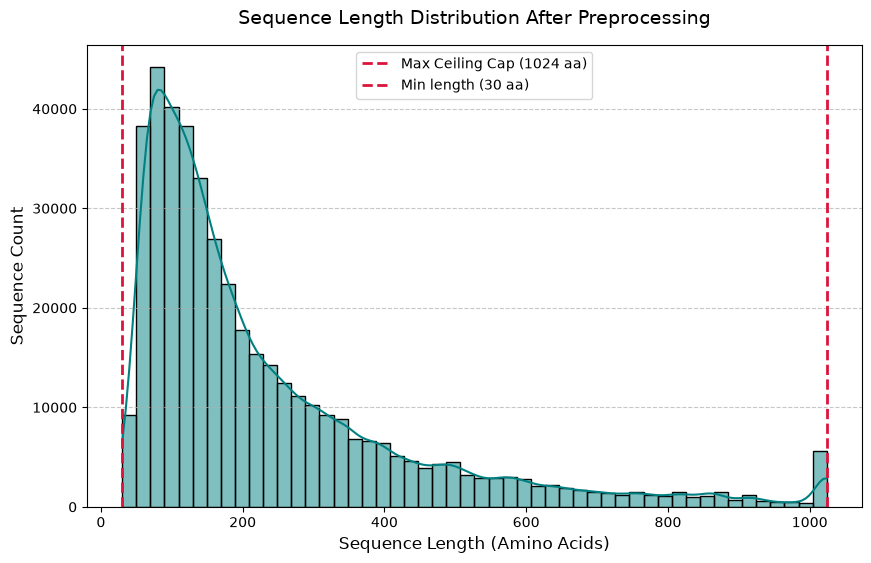

💾 Distribution plot successfully saved to: /users/antonios/pLMs_with_PHROGs/data/sequence_length_distribution.png


In [21]:
import io
import tarfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# base_dir and tar_path already defined by the earlier scanning cell
lengths = []

print("📦 Reading updated archive to extract sequence lengths...")

# ----------------------------------------------------
# 2. Extract and Parse Sequence Lengths from Tarball
# ----------------------------------------------------
with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar.getmembers():
        if member.isfile() and (member.name.endswith(".faa") or member.name.endswith(".fasta")):
            f = tar.extractfile(member)
            if f is not None:
                current_seq_len = 0

                for line in io.TextIOWrapper(f, encoding="utf-8"):
                    line = line.strip()
                    if line.startswith(">"):
                        if current_seq_len > 0:
                            lengths.append(current_seq_len)
                            current_seq_len = 0
                    elif line:
                        current_seq_len += len(line)

                if current_seq_len > 0:
                    lengths.append(current_seq_len)

len_series = pd.Series(lengths)

# ----------------------------------------------------
# 3. Print Statistical Report
# ----------------------------------------------------
print("\n" + "─" * 40)
print("📊 POST-PROCESSING SEQUENCE METRICS")
print("─" * 40)
print(f"🔹 Total Sequences Checked : {len(len_series):,}")
print(f"🔹 Maximum Sequence Length: {len_series.max()} aa")
print(f"🔹 Minimum Sequence Length: {len_series.min()} aa")
print(f"🔹 Mean Sequence Length   : {len_series.mean():.1f} aa")
print(f"🔹 Median Sequence Length : {len_series.median():.1f} aa")
print(f"🔹 Sequences at Max Limit : {sum(len_series == 1024):,} (Truncated/Capped)")
print("─" * 40)

# ----------------------------------------------------
# 4. Generate the Distribution Histogram
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(len_series, bins=50, kde=True, color="teal", edgecolor="black")
plt.axvline(1024, color="crimson", linestyle="--", linewidth=2, label="Max Ceiling Cap (1024 aa)")
plt.axvline(30, color="crimson", linestyle="--", linewidth=2, label="Min length (30 aa)")
plt.title("Sequence Length Distribution After Preprocessing", fontsize=14, pad=15)
plt.xlabel("Sequence Length (Amino Acids)", fontsize=12)
plt.ylabel("Sequence Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plot_output = base_dir / "sequence_length_distribution.png"
plt.savefig(plot_output, dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Distribution plot successfully saved to: {plot_output}")


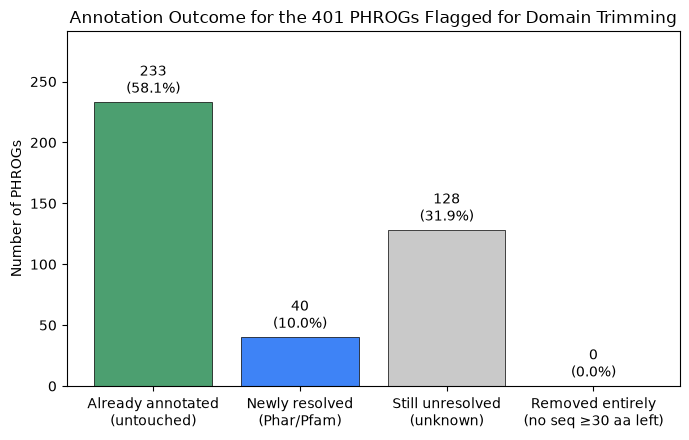

💾 Plot saved to: /users/antonios/pLMs_with_PHROGs/data/annotation_resolution_breakdown.png

🔹 Already annotated (untouched)          : 233
🔹 Newly resolved via HHsearch            : 40
🔹 Still unresolved (unknown or dark matter)              : 128
🔹 Removed entirely (no seq ≥30 aa left)  : 0

⚠️  Note: 40/40 newly-resolved PHROGs still show category='unknown function' — the 'category' column wasn't updated alongside 'annot'.


In [22]:
import matplotlib.pyplot as plt

with open(need_domains_path, "r") as f:
    target_phrog_ids = {int(line.strip()) for line in f if line.strip()}

sub = annot_df[annot_df["phrog"].isin(target_phrog_ids)].copy()
removed_ids = target_phrog_ids - set(annot_df["phrog"])

resolved_mask = sub["annot"].astype(str).str.startswith("Phar/Pfam:")
nan_mask = sub["annot"].isna()
already_mask = ~resolved_mask & ~nan_mask

categories = [
    "Already annotated\n(untouched)",
    "Newly resolved\n(Phar/Pfam)",
    "Still unresolved\n(unknown)",
    "Removed entirely\n(no seq \u226530 aa left)",
]
counts = [already_mask.sum(), resolved_mask.sum(), nan_mask.sum(), len(removed_ids)]
colors = ["#4c9f70", "#3e83f6", "#c9c9c9", "#e05252"]
total = sum(counts)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(categories, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts):
    pct = 100 * count / total
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
             f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Number of PHROGs")
ax.set_title(f"Annotation Outcome for the {total} PHROGs Flagged for Domain Trimming")
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()

plot_output = base_dir / "annotation_resolution_breakdown.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
plt.show()

print(f"💾 Plot saved to: {plot_output}")
print()
print(f"🔹 Already annotated (untouched)          : {already_mask.sum()}")
print(f"🔹 Newly resolved via HHsearch            : {resolved_mask.sum()}")
print(f"🔹 Still unresolved (unknown or dark matter)              : {nan_mask.sum()}")
print(f"🔹 Removed entirely (no seq \u226530 aa left)  : {len(removed_ids)}")

still_unknown_category = sub.loc[resolved_mask, "category"].eq("unknown function").sum()
print()
print(f"⚠️  Note: {still_unknown_category}/{resolved_mask.sum()} newly-resolved PHROGs still show "
      f"category='unknown function' — the 'category' column wasn't updated alongside 'annot'.")


/tmp/ipykernel_223759/3248596452.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


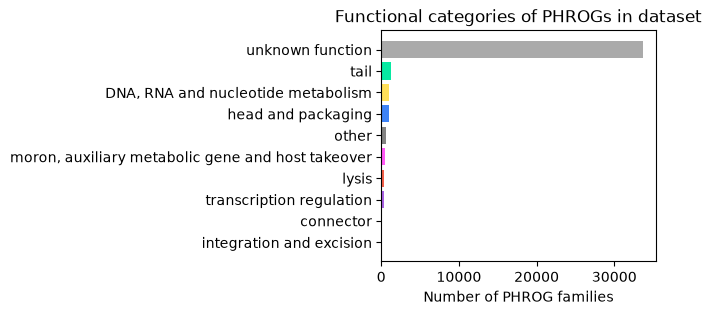

In [23]:
# Get PHROG IDs present in the FAA archive
phrog_ids = set()
with tarfile.open(tar_path) as t:
    for member in t.getmembers():
        if member.name.endswith(".faa"):
            name = member.name.split("/")[-1]          # phrog_10.faa
            pid = int(name.replace("phrog_", "").replace(".faa", ""))
            phrog_ids.add(pid)

annot = pd.read_csv("data/phrog_annot_v4_updated.tsv", sep="\t")
annot_map = annot.set_index("phrog")["category"].to_dict()

categories = [annot_map.get(pid, "unknown function") for pid in phrog_ids]
cat_counts = pd.Series(categories).value_counts().sort_values()

# category colours from PHROGs (one representative colour per category)
cat_color = (
    annot.dropna(subset=["category", "color"])
    .groupby("category")["color"]
    .first()
    .to_dict()
)
cat_color["unknown function"] = "#aaaaaa"
colors = [cat_color.get(c, "#aaaaaa") for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(3.54, 3.0))
ax.barh(cat_counts.index, cat_counts.values, color=colors, linewidth=0)
ax.set_xlabel("Number of PHROG families")
ax.set_title("Functional categories of PHROGs in dataset")
ax.tick_params(axis="y", pad=3)
plt.tight_layout()
plt.show()


In [24]:
# Check file size first — a truncated file will be suspiciously small
import os
size = os.path.getsize(tar_path)

print(f"File size: {size / 1e6:.1f} MB")

File size: 43.1 MB


In [25]:
from collections import Counter

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")
invalid_sequences = []
total_checked = 0

print("🔎 Validating FASTA sequences in the archive...")

with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar.getmembers():
        if not (member.isfile() and (member.name.endswith(".faa") or member.name.endswith(".fasta"))):
            continue
        f_in = tar.extractfile(member)
        if f_in is None:
            continue
        content = f_in.read().decode("utf-8")
        for header, seq in parse_fasta_string(content):
            total_checked += 1
            invalid_chars = set(seq) - VALID_AA
            if invalid_chars:
                invalid_sequences.append((member.name, header, invalid_chars))

print(f"🔹 Total sequences checked            : {total_checked:,}")
print(f"🔹 Sequences with non-canonical chars : {len(invalid_sequences):,}")

if invalid_sequences:
    char_freq = Counter()
    for _, _, chars in invalid_sequences:
        char_freq.update(chars)
    print("\n⚠️ Invalid character frequency:")
    for ch, count in char_freq.most_common():
        print(f"   '{ch}': {count}")


🔎 Validating FASTA sequences in the archive...
🔹 Total sequences checked            : 439,021
🔹 Sequences with non-canonical chars : 1,036

⚠️ Invalid character frequency:
   'X': 1021
   'B': 15
   'J': 12
   'Z': 11


Since those are just 1036 seqs can proceed without filtering them out

do proteins of the same function end up close together in the embedding space, even though the model was never told their function?

Attention maps in protein sequence analysis visualize how a machine learning model (usually a Transformer-based Protein Language Model) weighs the relationships between different amino acids. Interpret a sequence and predict its 3D folding and biological function

In [2]:
from pathlib import Path

base_dir = Path("/users/antonios/pLMs_with_PHROGs/data")

embed_output_path = base_dir / "esmc300m_embeddings.npy"
meta_output_path = base_dir / "esmc300m_embeddings_meta.tsv"
progress_path = base_dir / "esmc300m_embeddings.progress.json"

In [5]:
import numpy as np
import torch
import json
import csv

# Reuse model/tokenizer if already loaded
try:
    model, tokenizer
except NameError:
    from transformers import AutoModelForMaskedLM, AutoTokenizer
    model = AutoModelForMaskedLM.from_pretrained(
        "biohub/ESMC-300M", device_map="cuda:1", torch_dtype=torch.bfloat16
    ).eval()
    tokenizer = AutoTokenizer.from_pretrained("biohub/ESMC-300M")

BATCH_SIZE = 16
CHECKPOINT_EVERY = 50  # batches

embed_output_path = base_dir / "esmc300m_embeddings.npy"
meta_output_path = base_dir / "esmc300m_embeddings_meta.tsv"
progress_path = base_dir / "esmc300m_embeddings.progress.json"

In [8]:
#----------------------------------------------------
# 1. Pull every sequence (+ metadata) from the archive, length-sorted
#    so batches share similar length (less padding waste)
# ----------------------------------------------------
records = []  # (phrog_id, header, seq)
with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar.getmembers():
        match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)
        if not match:
            continue
        phrog_id = int(match.group(1))
        f_in = tar.extractfile(member)
        if f_in is None:
            continue
        content = f_in.read().decode("utf-8")
        for header, seq in parse_fasta_string(content):
            records.append((phrog_id, header, seq))

records.sort(key=lambda r: len(r[2]))
print(f"🧬 {len(records):,} sequences queued for embedding with biohub/ESMC-300M.")


NameError: name 'tarfile' is not defined

In [7]:
# ----------------------------------------------------
# 2. Resume from a previous run if a progress file exists
# ----------------------------------------------------
if progress_path.exists() and embed_output_path.exists():
    start_idx = json.loads(progress_path.read_text())["next_index"]
    mm = np.lib.format.open_memmap(embed_output_path, mode="r+")
    print(f"↩️  Resuming: {start_idx:,}/{len(records):,} sequences already embedded.")
else:
    start_idx = 0
    mm = None  # allocated once we know the hidden dim, after the first batch

with torch.inference_mode():
    for batch_num, i in enumerate(range(start_idx, len(records), BATCH_SIZE)):
        batch = records[i:i + BATCH_SIZE]
        seqs = [r[2] for r in batch]

        inputs = tokenizer(seqs, return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        output = model(**inputs)
        hidden = output.last_hidden_state

        mask = inputs["attention_mask"].unsqueeze(-1).to(hidden.dtype)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        pooled_np = pooled.float().cpu().numpy()

        if mm is None:
            mm = np.lib.format.open_memmap(
                embed_output_path, mode="w+", dtype="float32",
                shape=(len(records), pooled_np.shape[1]),
            )

        mm[i:i + len(batch)] = pooled_np

        if batch_num % CHECKPOINT_EVERY == 0:
            mm.flush()
            progress_path.write_text(json.dumps({"next_index": i + len(batch)}))
            print(f"  {i + len(batch):,}/{len(records):,} sequences embedded 💾")

mm.flush()
progress_path.write_text(json.dumps({"next_index": len(records)}))

# Metadata order is deterministic from `records`, so write it once at the end
with open(meta_output_path, "w", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["phrog_id", "header"])
    writer.writerows([(r[0], r[1]) for r in records])

progress_path.unlink()
print(f"✅ Done. Embeddings shape: {mm.shape}")
print(f"💾 Embeddings: {embed_output_path}")
print(f"💾 Metadata:   {meta_output_path}")

NameError: name 'records' is not defined

🧬 Running t-SNE on a 5% stratified-by-category sample: 21,951/439,021 embeddings
phrog_id
unknown function                                     10039
DNA, RNA and nucleotide metabolism                    2756
tail                                                  2741
head and packaging                                    2276
other                                                  948
transcription regulation                               837
lysis                                                  748
connector                                              700
moron, auxiliary metabolic gene and host takeover      504
integration and excision                               402
Name: count, dtype: int64


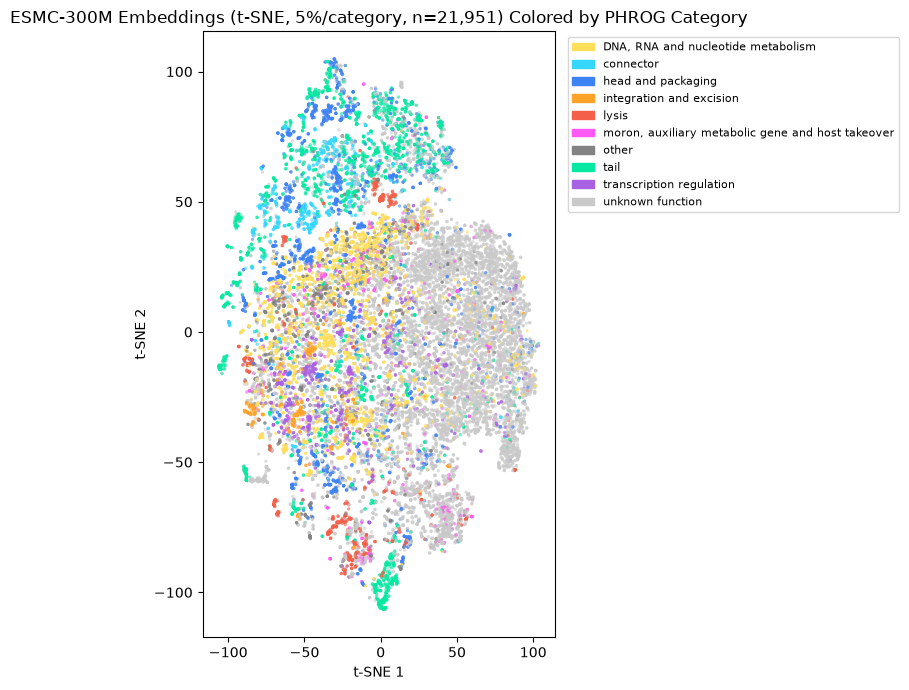

💾 Plot saved to: /users/antonios/pLMs_with_PHROGs/data/esmc300m_embeddings_tsne_stratified.png


In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 0. Load the REAL full-dataset embeddings from disk explicitly
# ----------------------------------------------------
embeddings = np.load(embed_output_path, mmap_mode="r")
meta_df = pd.read_csv(meta_output_path, sep="\t")
assert embeddings.shape[0] == len(meta_df), "embeddings/meta row count mismatch"

category_map = annot_df.set_index("phrog")["category"].to_dict()
full_categories = meta_df["phrog_id"].map(category_map).fillna("unknown function")

# ----------------------------------------------------
# 1. Stratified sample: 20% of EACH category, not 20% overall —
#    so every category (including small ones like "integration and
#    excision") is represented proportionally to itself, not swamped
#    by "unknown function".
# ----------------------------------------------------
SAMPLE_FRAC = 0.05
category_df = pd.DataFrame({"idx": np.arange(len(full_categories)), "category": full_categories.values})

sample_df = category_df.groupby("category", group_keys=False).sample(frac=SAMPLE_FRAC, random_state=42)
sample_idx = np.sort(sample_df["idx"].to_numpy())  # ascending order — faster sequential mmap reads

sample_embeddings = np.asarray(embeddings[sample_idx])
sample_categories = full_categories.iloc[sample_idx].reset_index(drop=True)

print(f"🧬 Running t-SNE on a {SAMPLE_FRAC:.0%} stratified-by-category sample: "
      f"{len(sample_idx):,}/{embeddings.shape[0]:,} embeddings")
print(sample_categories.value_counts())

# ----------------------------------------------------
# 2. PCA -> t-SNE
# ----------------------------------------------------
n_pca = min(50, sample_embeddings.shape[1])
reduced = PCA(n_components=n_pca, random_state=42).fit_transform(sample_embeddings)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(sample_embeddings) // 100)),
    init="pca",
    random_state=42,
    n_jobs=-1,
)
coords = tsne.fit_transform(reduced)

# ----------------------------------------------------
# 3. Plot, colored by category
# ----------------------------------------------------
cat_color = (
    annot_df.dropna(subset=["category", "color"])
    .groupby("category")["color"]
    .first()
    .to_dict()
)
cat_color["unknown function"] = "#c9c9c9"
point_colors = sample_categories.map(cat_color).fillna("#aaaaaa")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=6, alpha=0.6, linewidths=0)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"ESMC-300M Embeddings (t-SNE, {SAMPLE_FRAC:.0%}/category, n={len(sample_idx):,}) Colored by PHROG Category")

handles = [mpatches.Patch(color=v, label=k) for k, v in cat_color.items() if k in set(sample_categories)]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

plot_output = base_dir / "esmc300m_embeddings_tsne_stratified.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
plt.show()
print(f"💾 Plot saved to: {plot_output}")


The entire dataset

In [9]:
import tarfile
import pandas as pd
from pathlib import Path

PHROG_SEQ_TAR = Path("/users/antonios/pLMs_with_PHROGs/data/PHROG_sequences_len_filtered_faa.tar.gz")
PHROG_ANNOT_TSV = Path("/users/antonios/pLMs_with_PHROGs/data/phrog_annot_v4.tsv")

annot_df = pd.read_csv(PHROG_ANNOT_TSV, sep="\t")
category_map = annot_df.set_index("phrog")["category"].to_dict()

PHROG_sequences = {}

with tarfile.open(PHROG_SEQ_TAR, "r:gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        name = member.name.split("/")[-1]
        phrog_id = int(name.replace("phrog_", "").replace(".faa", ""))
        f = t.extractfile(member)
        if f is None:
            continue
        content = f.read().decode("utf-8")
        seqs = [seq for _, seq in parse_fasta_string(content) if seq]
        PHROG_sequences[phrog_id] = seqs

print(f"PHROGs loaded: {len(PHROG_sequences)}")
print(f"Total sequences: {sum(len(v) for v in PHROG_sequences.values())}")


PHROGs loaded: 38748
Total sequences: 866317


In [10]:
def get_category(pid):
    val = category_map.get(pid, "unknown function")
    if not isinstance(val, str) or val.lower() == "nan":
        return "unknown function"
    return val

known_categories = sorted(set(
    get_category(pid) for pid in PHROG_sequences
    if get_category(pid) != "unknown function"
))
category2idx = {cat: i for i, cat in enumerate(known_categories)}
idx2category = {i: cat for cat, i in category2idx.items()}

dark_matter_pids = [pid for pid in PHROG_sequences if get_category(pid) == "unknown function"]

print(f"  {len(known_categories)} known categories:")
for i, cat in enumerate(known_categories):
    print(f"    {i}: {cat}")

print(f"\n  {len(dark_matter_pids)} PHROGs with unknown function (dark matter)")
assert len(known_categories) > 0, "No categorized PHROGs found — check get_category"


  9 known categories:
    0: DNA, RNA and nucleotide metabolism
    1: connector
    2: head and packaging
    3: integration and excision
    4: lysis
    5: moron, auxiliary metabolic gene and host takeover
    6: other
    7: tail
    8: transcription regulation

  33631 PHROGs with unknown function (dark matter)


In [11]:
def embed_batch(model, tokenizer, seqs, batch_size=4, max_length=1024):
    """Tokenize seqs in chunks, mean-pool last_hidden_state over real tokens,
    return a list of per-sequence numpy vectors (same order as seqs)."""
    out = []
    with torch.inference_mode():
        for i in range(0, len(seqs), batch_size):
            chunk = seqs[i:i + batch_size]
            inputs = tokenizer(chunk, return_tensors="pt", padding=True,
                                truncation=True, max_length=max_length)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}
            hidden = model(**inputs).last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1).to(hidden.dtype)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            out.extend(pooled.float().cpu().numpy())
    return out


I need to find a way on how I need to deal with the sentences which vary in per phrog

Fine tuning


In [2]:
!pip install peft
import torch
import random
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForMaskedLM, AutoTokenizer,AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 3.6 MB/s  0:00:00



r: Controls the number of trainable parameters in the LoRA adapter matrices. A higher rank increases model capacity but also memory usage.

lora_alpha = Scales the strength of the fine-tuned adjustments in relation to the rank (r)

LoRA Dropout = A regularization technique that randomly sets a fraction of LoRA activations to zero during training to prevent overfitting. Not that useful, so we default set it to 0.



define the finetuned model


 ## This is a working supervised  baseline of the fine tuned model

During training, sequences from known PHROGs contribute a cross-entropy loss (predicted label vs true label). During embedding/t-SNE, you ignore the logits entirely and pull the encoder's hidden states instead

In [27]:
import gc

del model_ft
del optimizer
gc.collect()
torch.cuda.empty_cache()

NameError: name 'model_ft' is not defined

train test split

It loops over every PHROG, splits its sequences 80/20, and appends them to the train/val lists with the PHROG ID attached so the annotation never gets lost.

Family-wise (PHROG-ID-level) train/val/test split, stratified by category

For protein datasets, splitting by families (e.g., Pfam families) ensures that sequences from the same family do not appear in both training and test sets. This is critical for evaluating the model’s ability to generalize to unseen families.

This is the correct when I get the data that I need

train-val-test has to be in the final version. **Now it is train test**

In [ ]:
# from sklearn.model_selection import train_test_split
# from collections import Counter

# known_pids   = [pid for pid in PHROG_sequences if get_annot(pid) != "unknown"]
# unknown_pids = [pid for pid in PHROG_sequences if get_annot(pid) == "unknown"]

# # drop singleton classes entirely
# annot_counts    = Counter(get_annot(pid) for pid in known_pids)
# splittable_pids = [pid for pid in known_pids if annot_counts[get_annot(pid)] >= 2]
# dropped         = [pid for pid in known_pids if annot_counts[get_annot(pid)] < 2]

# print(f"Dropped {len(dropped)} PHROGs with singleton annotations: {sorted(set(get_annot(p) for p in dropped))}")

# train_pids, val_pids = train_test_split(
#     splittable_pids,
#     test_size=0.2,
#     random_state=42,
#     stratify=[get_annot(pid) for pid in splittable_pids]
# )

# train_pairs = [(s, pid) for pid in train_pids + unknown_pids for s in PHROG_sequences[pid]]
# val_pairs   = [(s, pid) for pid in val_pids for s in PHROG_sequences[pid]]

# print(f"Train: {len(train_pairs)} seqs | {len(train_pids)} known + {len(unknown_pids)} unknown PHROGs")
# print(f"Val:   {len(val_pairs)} seqs | {len(val_pids)} known PHROGs")

# # ── SANITY CHECKS ────────────────────────────────────────────────────────────
# assert set(train_pids).isdisjoint(set(val_pids)), "PHROG leakage"
# print("  OK: no PHROG appears in both train and val")

# val_annots = set(get_annot(pid) for pid in val_pids)
# print(f"  OK: {len(val_annots)} annotations represented in val")

80 20 train test on the seq - > train on 80% of each PHROGs and the 20% are for the prediction

####  Visualize the finetuned embeddings

### Test the classifier on the viral dark matter

In [6]:
import json
import re
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from peft import PeftModel
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# ----------------------------------------------------
# Paths — reuses the same deduped/cleaned archive and the adapter
# saved by the completed embedding_work_finetuned.py run
# ----------------------------------------------------
base_dir = Path("/users/antonios/pLMs_with_PHROGs/data")
PHROG_SEQ_TAR = base_dir / "FAA_phrog_deduped.tar.gz"
PHROG_ANNOT_TSV = base_dir / "phrog_annot_v4.tsv"

RESULTS_DIR = base_dir / "finetune_results"
ADAPTER_PATH = RESULTS_DIR / "esmc300m_lora_category_classifier"
TRAINING_RESULTS_PATH = RESULTS_DIR / "training_results.json"

DEVICE = "cuda:1"
BATCH_SIZE = 16
CONFIDENCE_THRESHOLD = 0.65

# Load known_categories from the training run itself, so the probability
# columns line up with the classifier head's actual trained label order
training_results = json.loads(TRAINING_RESULTS_PATH.read_text())
known_categories = training_results["known_categories"]
print(f"Loaded {len(known_categories)} known categories from training run: {known_categories}")

# Annotations + sequences (self-contained reload, same pattern as your
# "entire dataset" cell earlier in the notebook)
annot_df = pd.read_csv(PHROG_ANNOT_TSV, sep="\t")
category_map = annot_df.set_index("phrog")["category"].to_dict()


def get_category(pid):
    val = category_map.get(pid, "unknown function")
    if not isinstance(val, str) or val.lower() == "nan":
        return "unknown function"
    return val


PHROG_sequences = {}
with tarfile.open(PHROG_SEQ_TAR, "r:gz") as t:
    for member in t.getmembers():
        match = re.search(r'phrog_(\d+)\.(faa|fasta)$', member.name)
        if not match:
            continue
        pid = int(match.group(1))
        f = t.extractfile(member)
        if f is None:
            continue
        content = f.read().decode("utf-8")
        seqs = [seq for _, seq in parse_fasta_string(content) if seq]
        PHROG_sequences[pid] = seqs

dark_matter_pids = [pid for pid in PHROG_sequences if get_category(pid) == "unknown function"]
print(f"{len(dark_matter_pids)} dark-matter (unknown function) PHROGs found in the archive")


Loaded 9 known categories from training run: ['DNA, RNA and nucleotide metabolism', 'connector', 'head and packaging', 'integration and excision', 'lysis', 'moron, auxiliary metabolic gene and host takeover', 'other', 'tail', 'transcription regulation']
33631 dark-matter (unknown function) PHROGs found in the archive


In [12]:
dark_matter_pairs = []  # (seq, pid)
n_before, n_after = 0, 0
for pid in dark_matter_pids:
    seqs = PHROG_sequences[pid]
    n_before += len(seqs)
    unique_seqs = list(dict.fromkeys(seqs))  # preserves first-seen order
    n_after += len(unique_seqs)
    dark_matter_pairs.extend((s, pid) for s in unique_seqs)

print(f"Dark-matter sequences before dedup: {n_before:,}")
print(f"Dark-matter sequences after within-PHROG dedup: {n_after:,} "
      f"({(n_before - n_after) / n_before:.1%} removed)")


Dark-matter sequences before dedup: 200,784
Dark-matter sequences after within-PHROG dedup: 200,784 (0.0% removed)


In [20]:
print(f"Loading biohub/ESMC-300M + LoRA adapter onto {DEVICE}...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    "biohub/ESMC-300M",
    device_map=DEVICE,
    torch_dtype=torch.bfloat16,
    num_labels=len(known_categories),
)
model_ft = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model_ft.eval()

tokenizer_ft = AutoTokenizer.from_pretrained("biohub/ESMC-300M")


Loading biohub/ESMC-300M + LoRA adapter onto cuda:1...


Some weights of ESMCForSequenceClassification were not initialized from the model checkpoint at biohub/ESMC-300M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
dark_matter_pairs.sort(key=lambda p: len(p[0]))  # length-bucket, less padding waste

embed_output_path = RESULTS_DIR / "dark_matter_embeddings.npy"
meta_output_path = RESULTS_DIR / "dark_matter_embeddings_meta.tsv"

mm = None
meta_rows = []  # (phrog_id, *per-category probability columns)

print(f"Running inference on {len(dark_matter_pairs):,} deduplicated dark-matter sequences...")
with torch.inference_mode():
    for i in tqdm(range(0, len(dark_matter_pairs), BATCH_SIZE), desc="Dark matter inference"):
        chunk = dark_matter_pairs[i:i + BATCH_SIZE]
        seqs = [c[0] for c in chunk]
        pids = [c[1] for c in chunk]

        inputs = tokenizer_ft(seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024)
        inputs = {k: v.to(model_ft.device) for k, v in inputs.items()}

        output = model_ft(**inputs, output_hidden_states=True)
        probs = F.softmax(output.logits.float(), dim=-1).cpu().numpy()

        hidden = output.hidden_states[-1]
        mask = inputs["attention_mask"].unsqueeze(-1).to(hidden.dtype)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        pooled_np = pooled.float().cpu().numpy()

        if mm is None:
            mm = np.lib.format.open_memmap(
                embed_output_path, mode="w+", dtype="float32",
                shape=(len(dark_matter_pairs), pooled_np.shape[1]),
            )

        mm[i:i + len(chunk)] = pooled_np
        for pid, p in zip(pids, probs):
            meta_rows.append((pid, *p.tolist()))

mm.flush()
meta_df = pd.DataFrame(meta_rows, columns=["phrog_id", *known_categories])
meta_df.to_csv(meta_output_path, sep="\t", index=False)
print(f"Saved dark-matter embeddings {mm.shape} to {embed_output_path}")
print(f"Saved per-sequence category probabilities to {meta_output_path}")


Running inference on 200,784 deduplicated dark-matter sequences...


Dark matter inference: 100%|██████████| 12549/12549 [30:43<00:00,  6.81it/s]


Saved dark-matter embeddings (200784, 960) to /users/antonios/pLMs_with_PHROGs/data/finetune_results/dark_matter_embeddings.npy
Saved per-sequence category probabilities to /users/antonios/pLMs_with_PHROGs/data/finetune_results/dark_matter_embeddings_meta.tsv


In [22]:
phrog_probs = meta_df.groupby("phrog_id")[known_categories].mean()
predicted_category = phrog_probs.idxmax(axis=1)
confidence = phrog_probs.max(axis=1)
n_sequences = meta_df.groupby("phrog_id").size()

predictions_df = pd.DataFrame({
    "phrog_id": phrog_probs.index,
    "predicted_category": predicted_category.values,
    "confidence": confidence.values,
    "n_sequences": n_sequences.reindex(phrog_probs.index).values,
}).sort_values("confidence", ascending=False).reset_index(drop=True)

predictions_path = RESULTS_DIR / "dark_matter_predictions.tsv"
predictions_df.to_csv(predictions_path, sep="\t", index=False)
print(f"Saved per-PHROG predictions to {predictions_path}")
predictions_df.head(10)


Saved per-PHROG predictions to /users/antonios/pLMs_with_PHROGs/data/finetune_results/dark_matter_predictions.tsv


,phrog_id,predicted_category,confidence,n_sequences
0,32108,"DNA, RNA and nucleotide metabolism",0.924402,2
1,15333,"DNA, RNA and nucleotide metabolism",0.924367,1
2,16760,"DNA, RNA and nucleotide metabolism",0.924258,5
3,25155,"DNA, RNA and nucleotide metabolism",0.924246,2
4,36772,"DNA, RNA and nucleotide metabolism",0.924168,1
5,25205,"DNA, RNA and nucleotide metabolism",0.924167,1
6,23353,"DNA, RNA and nucleotide metabolism",0.924158,3
7,33614,"DNA, RNA and nucleotide metabolism",0.924137,2
8,36008,"DNA, RNA and nucleotide metabolism",0.924120,1
9,28855,"DNA, RNA and nucleotide metabolism",0.924111,1


────────────────────────────────────────────────────────────
SUMMARY (confidence threshold = 0.65)
────────────────────────────────────────────────────────────
Total dark-matter PHROGs projected  : 33,631
Confidently assigned (>= 0.65)    : 10,280 (30.6%)

Predicted category breakdown (confidently assigned only):
predicted_category
DNA, RNA and nucleotide metabolism    5350
head and packaging                    2458
tail                                  1762
transcription regulation               522
connector                              188
Name: count, dtype: int64


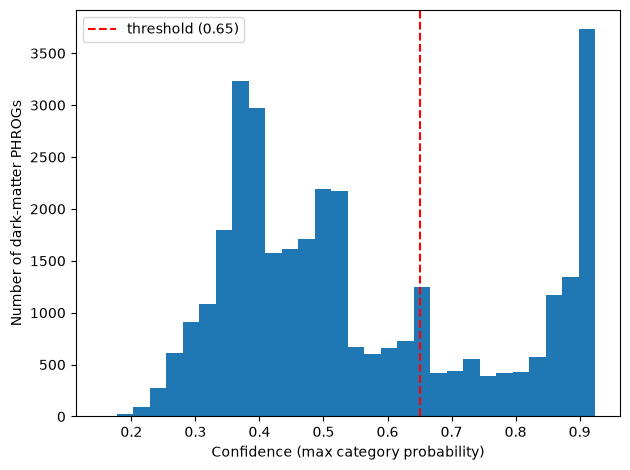

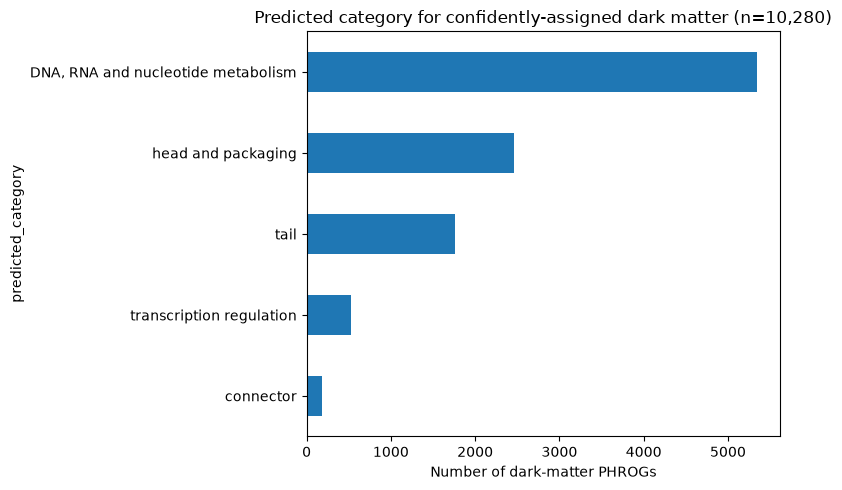

In [23]:
confident = predictions_df[predictions_df["confidence"] >= CONFIDENCE_THRESHOLD]
print("─" * 60)
print(f"SUMMARY (confidence threshold = {CONFIDENCE_THRESHOLD})")
print("─" * 60)
print(f"Total dark-matter PHROGs projected  : {len(predictions_df):,}")
print(f"Confidently assigned (>= {CONFIDENCE_THRESHOLD})    : "
      f"{len(confident):,} ({len(confident) / len(predictions_df):.1%})")
print("\nPredicted category breakdown (confidently assigned only):")
print(confident["predicted_category"].value_counts())

plt.figure()
plt.hist(predictions_df["confidence"], bins=30, edgecolor="none")
plt.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", label=f"threshold ({CONFIDENCE_THRESHOLD})")
plt.xlabel("Confidence (max category probability)")
plt.ylabel("Number of dark-matter PHROGs")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dark_matter_confidence_histogram.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
confident["predicted_category"].value_counts().sort_values().plot.barh()
plt.xlabel("Number of dark-matter PHROGs")
plt.title(f"Predicted category for confidently-assigned dark matter (n={len(confident):,})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dark_matter_predicted_category_breakdown.png", dpi=200)
plt.show()


Visualize the test set sequences 

Restricting to test split only: 35,538/238,237 sequences


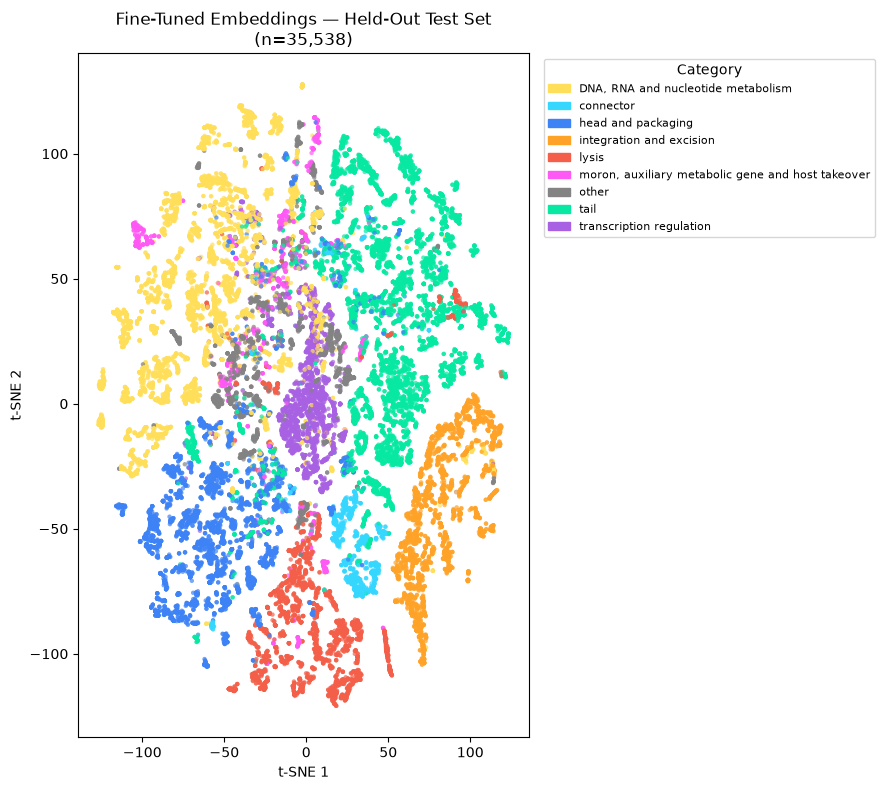

💾 Plot saved to: /users/antonios/pLMs_with_PHROGs/data/finetune_results/test_set_tsne.png


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ----------------------------------------------------
# Load fine-tuned embeddings, restrict to TEST split only
# (train was directly optimized on; test is what the headline
# accuracy/F1 numbers were reported on, so using it here keeps
# the figure consistent with the reported metrics)
# ----------------------------------------------------
labeled_embeddings = np.load(RESULTS_DIR / "esmc300m_finetuned_embeddings.npy", mmap_mode="r")
labeled_meta = pd.read_csv(RESULTS_DIR / "esmc300m_finetuned_embeddings_meta.tsv", sep="\t")
assert labeled_embeddings.shape[0] == len(labeled_meta)

test_idx = np.where((labeled_meta["split"] == "test").to_numpy())[0]
print(f"Restricting to test split only: {len(test_idx):,}/{len(labeled_meta):,} sequences")

test_emb = np.asarray(labeled_embeddings[test_idx])
test_categories = labeled_meta["category"].iloc[test_idx].reset_index(drop=True)

# ----------------------------------------------------
# PCA -> t-SNE on the test set alone
# ----------------------------------------------------
n_pca = min(50, test_emb.shape[1])
reduced = PCA(n_components=n_pca, random_state=42).fit_transform(test_emb)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(test_emb) // 100)),
    init="pca",
    random_state=42,
    n_jobs=-1,
)
coords = tsne.fit_transform(reduced)

# ----------------------------------------------------
# Plot: test-set categories only
# ----------------------------------------------------
cat_color = (
    annot_df.dropna(subset=["category", "color"])
    .groupby("category")["color"]
    .first()
    .to_dict()
)

fig, ax = plt.subplots(figsize=(9, 8))
point_colors = test_categories.map(cat_color).fillna("#aaaaaa")
ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=10, alpha=0.7, linewidths=0)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"Fine-Tuned Embeddings — Held-Out Test Set\n(n={len(test_idx):,})")

handles = [mpatches.Patch(color=v, label=k) for k, v in cat_color.items() if k in set(test_categories)]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Category")
plt.tight_layout()

plot_output = RESULTS_DIR / "test_set_tsne.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
plt.show()
print(f"💾 Plot saved to: {plot_output}")


Dark matter sampled: 200,784 total | 59,462 confident (>= 0.65) | 141,322 non-confident


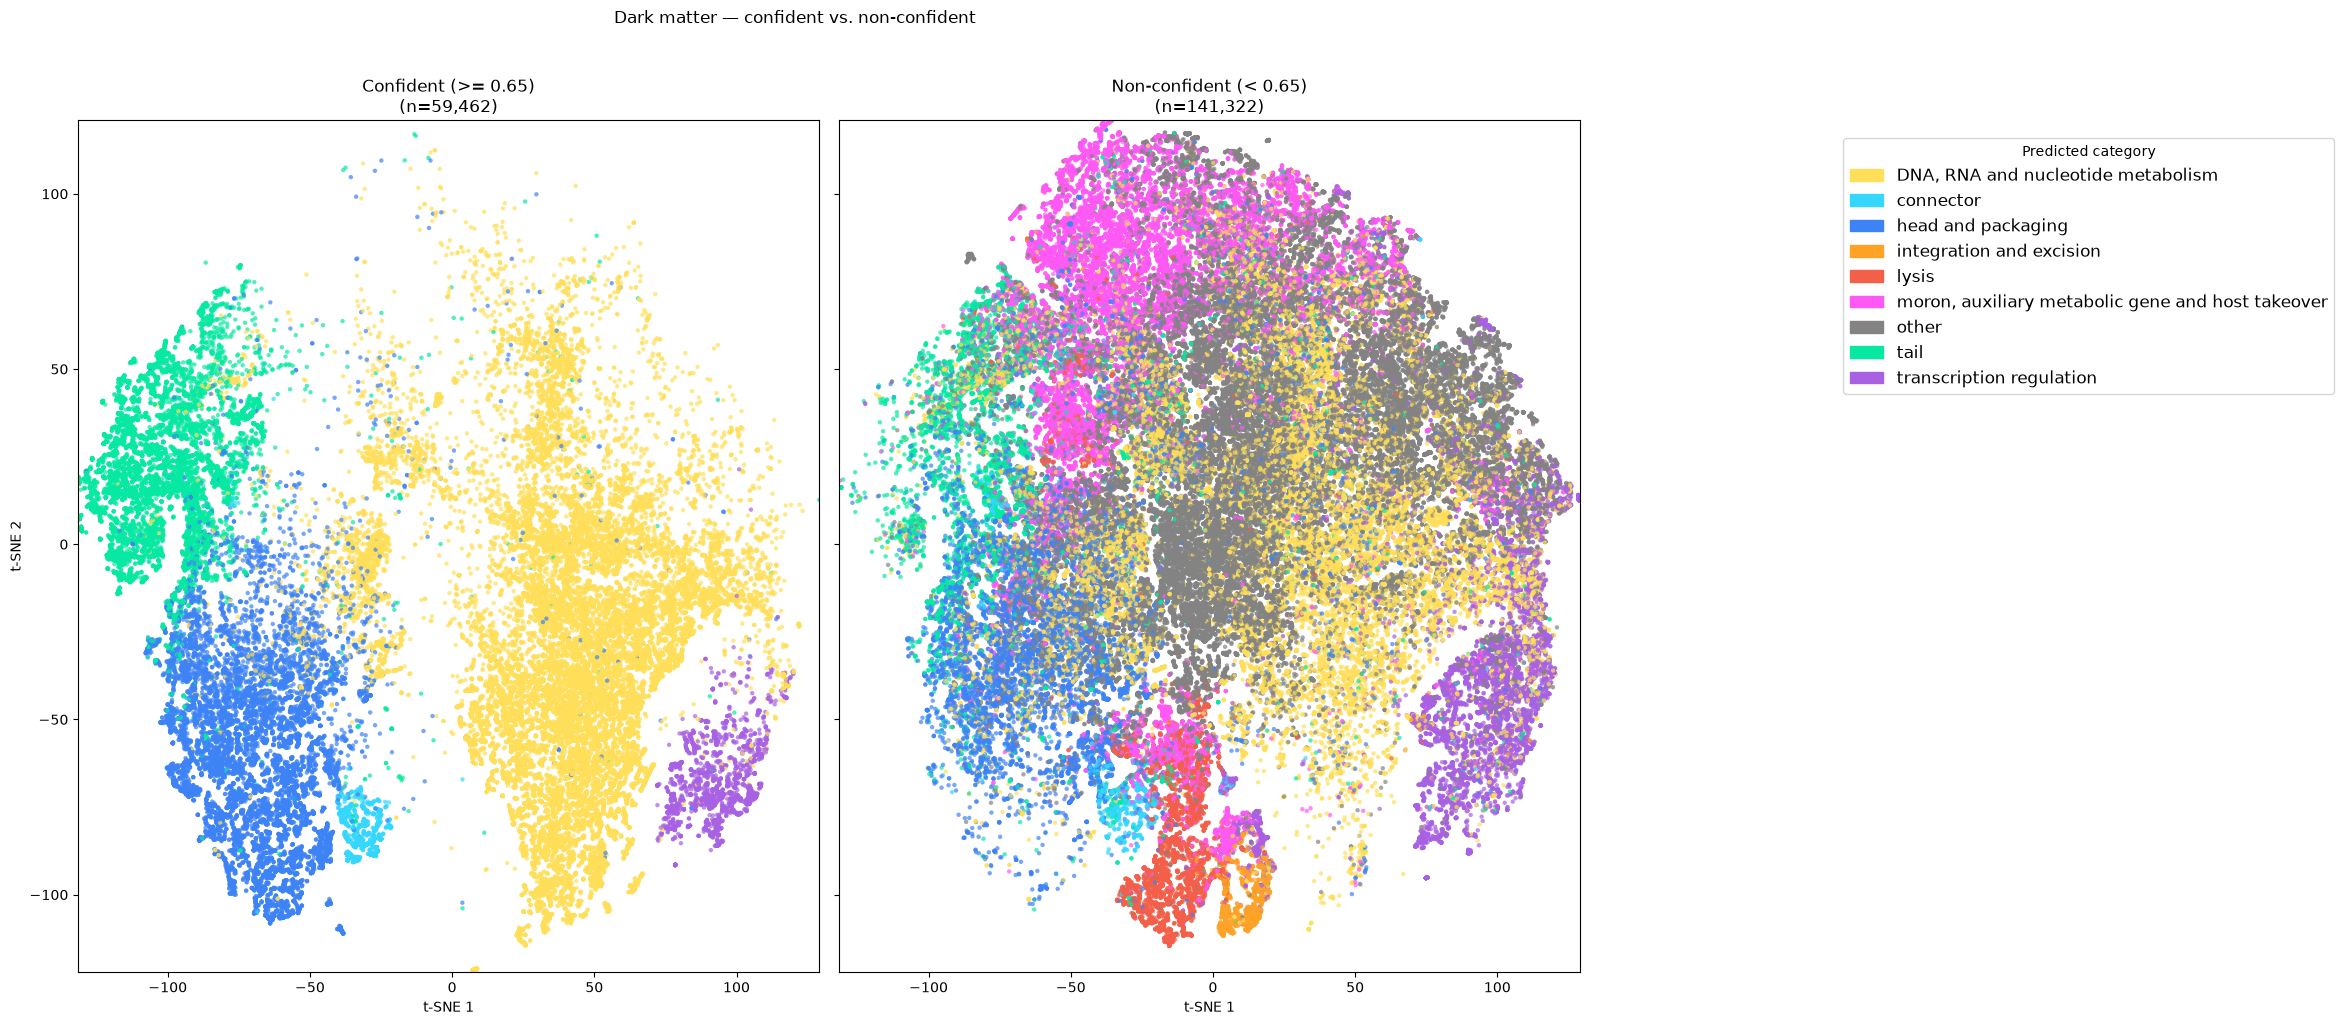

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ----------------------------------------------------
# Load dark-matter embeddings + per-PHROG predictions
# ----------------------------------------------------
CONFIDENCE_THRESHOLD = 0.65
DARK_FRAC = 1.0  # dark matter is large; sample for t-SNE tractability

dm_embeddings = np.load(RESULTS_DIR / "dark_matter_embeddings.npy", mmap_mode="r")
dm_meta = pd.read_csv(RESULTS_DIR / "dark_matter_embeddings_meta.tsv", sep="\t")
dm_predictions = pd.read_csv(RESULTS_DIR / "dark_matter_predictions.tsv", sep="\t").set_index("phrog_id")

dm_meta["predicted_category"] = dm_meta["phrog_id"].map(dm_predictions["predicted_category"])
dm_meta["confidence"] = dm_meta["phrog_id"].map(dm_predictions["confidence"])

dm_idx_df = pd.DataFrame({"idx": np.arange(len(dm_meta)), "category": dm_meta["predicted_category"].values})
dm_sample = dm_idx_df.groupby("category", group_keys=False).sample(frac=DARK_FRAC, random_state=42)
dm_sample_idx = np.sort(dm_sample["idx"].to_numpy())

dm_sample_emb = np.asarray(dm_embeddings[dm_sample_idx])
dm_predicted_cat_sampled = dm_meta["predicted_category"].iloc[dm_sample_idx].to_numpy()
dm_confidence_sampled = dm_meta["confidence"].iloc[dm_sample_idx].to_numpy()
confident_mask = dm_confidence_sampled >= CONFIDENCE_THRESHOLD

print(f"Dark matter sampled: {len(dm_sample_idx):,} total | "
      f"{confident_mask.sum():,} confident (>= {CONFIDENCE_THRESHOLD}) | "
      f"{(~confident_mask).sum():,} non-confident")

# ----------------------------------------------------
# PCA -> t-SNE on dark matter alone
# ----------------------------------------------------
n_pca = min(50, dm_sample_emb.shape[1])
reduced = PCA(n_components=n_pca, random_state=42).fit_transform(dm_sample_emb)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(dm_sample_emb) // 100)),
    init="pca",
    random_state=42,
    n_jobs=-1,
)
dm_coords = tsne.fit_transform(reduced)

x_min, x_max = dm_coords[:, 0].min(), dm_coords[:, 0].max()
y_min, y_max = dm_coords[:, 1].min(), dm_coords[:, 1].max()

# ----------------------------------------------------
# Plot: dark matter only, split by confidence, colored by predicted category
# ----------------------------------------------------
cat_color = (
    annot_df.dropna(subset=["category", "color"])
    .groupby("category")["color"]
    .first()
    .to_dict()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)

for ax, mask, title in [
    (axes[0], confident_mask, f"Confident (>= {CONFIDENCE_THRESHOLD})"),
    (axes[1], ~confident_mask, f"Non-confident (< {CONFIDENCE_THRESHOLD})"),
]:
    cats = dm_predicted_cat_sampled[mask]
    colors = pd.Series(cats).map(cat_color).fillna("#aaaaaa")
    ax.scatter(dm_coords[mask, 0], dm_coords[mask, 1], c=colors, s=10, alpha=0.7, linewidths=0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("t-SNE 1")
    ax.set_title(f"{title}\n(n={mask.sum():,})")

axes[0].set_ylabel("t-SNE 2")
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_color.items()
           if k in set(dm_predicted_cat_sampled)]
fig.legend(handles=handles, bbox_to_anchor=(1.15, 0.9), loc="upper left", fontsize=12, title="Predicted category")
fig.suptitle("Dark matter — confident vs. non-confident", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dark_matter_confident_vs_nonconfident_tsne.png", dpi=300, bbox_inches="tight")
plt.show()


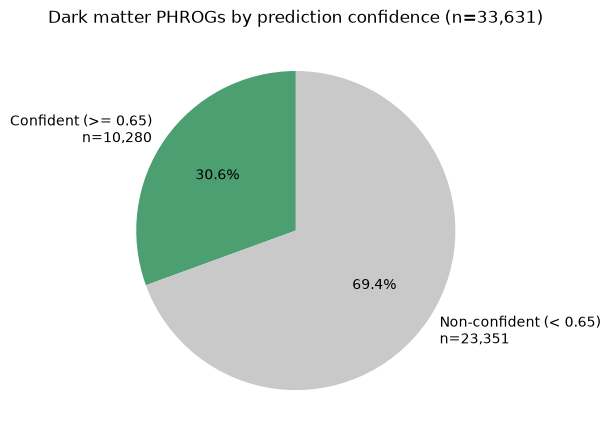

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

dm_predictions = pd.read_csv(RESULTS_DIR / "dark_matter_predictions.tsv", sep="\t")

n_confident = (dm_predictions["confidence"] >= CONFIDENCE_THRESHOLD).sum()
n_non_confident = len(dm_predictions) - n_confident

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [n_confident, n_non_confident],
    labels=[f"Confident (>= {CONFIDENCE_THRESHOLD})\nn={n_confident:,}",
            f"Non-confident (< {CONFIDENCE_THRESHOLD})\nn={n_non_confident:,}"],
    autopct="%1.1f%%",
    colors=["#4c9f70", "#c9c9c9"],
    startangle=90,
)
ax.set_title(f"Dark matter PHROGs by prediction confidence (n={len(dm_predictions):,})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dark_matter_confidence_pie.png", dpi=300, bbox_inches="tight")
plt.show()


What we show here? 

"Is there evidence this approach could work?

this shows the model's predictions are internally consistent (confident dark-matter predictions land where they should, given what the model learned), not that they're biologically correct. You haven't independently verified any specific dark-matter PHROG's predicted function against external evidence (structural homology, distant search hits, experimental data). That's fine — it's expected future work, not a missing piece of this PoC — but state it explicitly as a limitation rather than implying the predictions are validated biology. With that caveat stated, this stands on its own.